**INTRODUCTION**

Credit risk assessment is a critical component of modern lending, as it enables financial institutions to make informed decisions while minimizing the risk of loan defaults. In this project, we develop a machine learning model to predict whether a loan applicant is likely to repay a loan successfully (Good = 1) or default (Bad = 0) using data from the Zindi SuperLender Loan Default Prediction Challenge. The analysis follows a structured data science workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction generation. The goal is to identify patterns associated with loan repayment behavior and build an accurate predictive model that can support better lending decisions.

**DATASET DESCRIPTION**

The dataset used in this project  contains three interconnected data sets that provide  information on customer demographics, current loan performance, and previous borrowing history.These are



*   **The Demographic Data** dataset contains customer characteristics such as age, bank account details, location, employment status, and education level.
*  **The Performance Data** dataset contains information on the current loan under evaluation, including loan amount, repayment amount, loan term, approval date, and the target variable.

*  **The Previous Loans Data** dataset contains historical borrowing and repayment records, including previous loan amounts, repayment schedules, settlement dates, and repayment behavior.












**DATA LOADING AND INSPECTION**
The first step in the analysis is to load thethree training datasets in Google Colab and inspect the structure.his process helps to understand the dimensions of the datasets, identify the available variables, examine data types, and detect any obvious data quality issues such as missing values or inconsistencies

In [ ]:
#Importing the required libraries
import pandas as pd
import numpy as np

#load train datasets
demographics=pd.read_csv('/content/traindemographics.csv')
performance=pd.read_csv('/content/trainperf.csv')
previous=pd.read_csv('/content/trainprevloans.csv')


In [ ]:
#Display dataset dimensions
print("Demographics Shape:", demographics.shape)
print("Performance Shape:", performance.shape)
print("Previous Loans Shape:", previous.shape)

Demographics Shape: (4346, 9)
Performance Shape: (4368, 10)
Previous Loans Shape: (18183, 12)


In [ ]:
#Display first few rows
display(demographics.head())
display(performance.head())
display(previous.head())

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.319219,6.528604,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.325598,7.119403,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.746100,5.563174,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.362850,6.642485,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.455332,11.971410,GT Bank,NaN,Permanent,NaN


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0,34500.0,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0,17250.0,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0,22250.0,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0,11500.0,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0,44000.0,30,NaN,Good


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.0,13000.0,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.0,13000.0,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.0,23800.0,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.0,11500.0,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.0,11500.0,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


In [ ]:
#Check data types and missing values
print("\nDemographics Info:")
print(demographics.info())
print("\nPerformance Info:")
print(performance.info())
print("\nPrevious Loans Info:")
print(previous.info())


Demographics Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4346 non-null   object 
 1   birthdate                   4346 non-null   object 
 2   bank_account_type           4346 non-null   object 
 3   longitude_gps               4346 non-null   float64
 4   latitude_gps                4346 non-null   float64
 5   bank_name_clients           4346 non-null   object 
 6   bank_branch_clients         51 non-null     object 
 7   employment_status_clients   3698 non-null   object 
 8   level_of_education_clients  587 non-null    object 
dtypes: float64(2), object(7)
memory usage: 305.7+ KB
None

Performance Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------       

**Initial data inspection summary**

The initial inspection showed that three datasets contain customer demographic informaiton, current loan details, and historical loan records. While most variables are compplete, several fields contain signifcant missing values, particularly bank_branch_clients, level_of_education_clients, and refferedby.
All the date related are also stored as texts and will require conversion  to datetime format before analysis  

DATA CLEANING AND PREPROCESSING
In this stage, the data cleaning and preprocessing process aims to address the issues identified during the initial data inspection and prepare the datasets for analysis and model development. This involves assessing the completeness and quality of the data, identifying any duplicate records, and ensuring that variables are stored in appropriate formats. Particular attention is given to date-related variables, which need to be converted to datetime format to support temporal analysis and feature engineering. Any additional data quality issues identified during the process are also addressed to improve the reliability and consistency of the final analytical dataset.

The main data cleaning activities include:

* Checking for missing values in each dataset.
* Identifying and handling duplicate records.
* Converting date variables to datetime format.
* Addressing any additional data quality issues identified during the analysis



In [ ]:
#Check missing values in each dataset
print("Missing Values in Demographics:")
print(demographics.isnull().sum())
print("\nMissing Values in Performance:")
print(performance.isnull().sum())
print("\nMissing Values in Previous Loans:")
print(previous.isnull().sum())

Missing Values in Demographics:
customerid                       0
birthdate                        0
bank_account_type                0
longitude_gps                    0
latitude_gps                     0
bank_name_clients                0
bank_branch_clients           4295
employment_status_clients      648
level_of_education_clients    3759
dtype: int64

Missing Values in Performance:
customerid          0
systemloanid        0
loannumber          0
approveddate        0
creationdate        0
loanamount          0
totaldue            0
termdays            0
referredby       3781
good_bad_flag       0
dtype: int64

Missing Values in Previous Loans:
customerid             0
systemloanid           0
loannumber             0
approveddate           0
creationdate           0
loanamount             0
totaldue               0
termdays               0
closeddate             0
referredby         17157
firstduedate           0
firstrepaiddate        0
dtype: int64


In [ ]:
#Percentage of missing values
for name, df in {
    'Demographics':demographics,
    'Performance':performance,
    'Previous loans':previous
}.items():
    missing=(df.isnull().sum()/len(df))*100
    missing=missing[missing>0].sort_values(ascending=False)

    print(f"\n{name} Dataset")
    print(missing)


Demographics Dataset
bank_branch_clients           98.826507
level_of_education_clients    86.493327
employment_status_clients     14.910262
dtype: float64

Performance Dataset
referredby    86.561355
dtype: float64

Previous loans Dataset
referredby    94.357367
dtype: float64


Assessment reveals that some variables contain incomplete records.
* Demographic dataset:bank_branch_clients , level_of_education_clients, and employment_status_clients
* Performance and previous loans datasets:referredby has substantial number of missing values

In [ ]:
#Checking duplicate records
print("Duplicate records in Demographics:", demographics.duplicated().sum())
print("Duplicate records in Performance:", performance.duplicated().sum())
print("Duplicate records in Previous Loans:", previous.duplicated().sum())

Duplicate records in Demographics: 12
Duplicate records in Performance: 0
Duplicate records in Previous Loans: 0


Duplicated records
The demographic dataset contains 12 duplicate records. These should be investigated and removed where appropriate. This helps mantain data integrirt and prevent potential bias during analyis and model training

In [ ]:
#view duplicate records
duplicates=demographics[demographics.duplicated(keep=False)]

print(f"Number of duplicate rows:{duplicates.shape[0]}")
duplicates.sort_values('customerid')

Number of duplicate rows:24


,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
1414,8a858e625c8d993a015c938f829f77ee,1988-12-20 00:00:00.000000,Savings,5.768333,5.561992,First Bank,NaN,Permanent,NaN
1928,8a858e625c8d993a015c938f829f77ee,1988-12-20 00:00:00.000000,Savings,5.768333,5.561992,First Bank,NaN,Permanent,NaN
445,8a858e6c5c88d145015c8b9627cd5a48,1979-09-30 00:00:00.000000,Savings,3.367008,6.497313,Sterling Bank,NaN,Permanent,NaN
1090,8a858e6c5c88d145015c8b9627cd5a48,1979-09-30 00:00:00.000000,Savings,3.367008,6.497313,Sterling Bank,NaN,Permanent,NaN
1996,8a858ec65cc6352b015cc64525ea0763,1985-01-30 00:00:00.000000,Savings,3.845728,7.411737,GT Bank,NaN,Permanent,NaN
1520,8a858ec65cc6352b015cc64525ea0763,1985-01-30 00:00:00.000000,Savings,3.845728,7.411737,GT Bank,NaN,Permanent,NaN
272,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18 00:00:00.000000,Other,3.782563,7.171356,First Bank,NaN,Permanent,Secondary
517,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18 00:00:00.000000,Other,3.782563,7.171356,First Bank,NaN,Permanent,Secondary
4126,8a858f1e5baffcc9015bb02b505f180d,1983-04-06 00:00:00.000000,Savings,6.969350,4.818535,GT Bank,NaN,Permanent,NaN
3021,8a858f1e5baffcc9015bb02b505f180d,1983-04-06 00:00:00.000000,Savings,6.969350,4.818535,GT Bank,NaN,Permanent,NaN


The records are identical  which indicates likely duplication during data cillection or extraction. The duplicates should be removed

In [ ]:
#Remove exact duplicate records
demographics=demographics.drop_duplicates()

#Verify duplicates have been removed
print("Duplicate records in Demographics:", demographics.duplicated().sum())

Duplicate records in Demographics: 0


**Converting date variables**
A number of variables within the dataset stor  date and time information currently stored as text. They need to be converted to datetime format is necessary to enable temporal anaysis and feature engineering. This conversion allows for extraction of useful information such as customer age, loan processing times, repayment delays, and historical borrowing patterns

In [ ]:
#Convert date columns in demographic dataset

demographics['birthdate']=pd.to_datetime(demographics['birthdate'])

#Convert date columns in performance dataset
performance['approveddate']=pd.to_datetime(performance['approveddate'])
performance['creationdate']=pd.to_datetime(performance['creationdate'] )


# Convert date columns in previous loans dataset
date_columns = [
    'approveddate',
    'creationdate',
    'closeddate',
    'firstduedate',
    'firstrepaiddate'
]

for col in date_columns:
    previous[col] = pd.to_datetime(previous[col])


In [ ]:
#Verify conversion

print("\nDemographics Data Types")
print(demographics.dtypes)

print("\nPerformance Data Types")
print(performance.dtypes)

print("\nPrevious Loans Data Types")
print(previous.dtypes)


Demographics Data Types
customerid                            object
birthdate                     datetime64[ns]
bank_account_type                     object
longitude_gps                        float64
latitude_gps                         float64
bank_name_clients                     object
bank_branch_clients                   object
employment_status_clients             object
level_of_education_clients            object
dtype: object

Performance Data Types
customerid               object
systemloanid              int64
loannumber                int64
approveddate     datetime64[ns]
creationdate     datetime64[ns]
loanamount              float64
totaldue                float64
termdays                  int64
referredby               object
good_bad_flag            object
dtype: object

Previous Loans Data Types
customerid                 object
systemloanid                int64
loannumber                  int64
approveddate       datetime64[ns]
creationdate       datetime64[ns]
l

**Missing value treatment **

An appropriate treatment strategy should be applied depending on the nature and importance of each variable
* Variables with high missingness are evaluated to determine whether to be retained or dropped
* Categorical variables are filled with placeholder category such as "Unknown"
* Numerical variables are either imputed  using mean, median, or mode or left unchanged if not significant

In [ ]:
#Check missing values again
print(demographics.isnull().sum())
print(performance.isnull().sum())
print(previous.isnull().sum())

customerid                       0
birthdate                        0
bank_account_type                0
longitude_gps                    0
latitude_gps                     0
bank_name_clients                0
bank_branch_clients           4283
employment_status_clients      648
level_of_education_clients    3748
dtype: int64
customerid          0
systemloanid        0
loannumber          0
approveddate        0
creationdate        0
loanamount          0
totaldue            0
termdays            0
referredby       3781
good_bad_flag       0
dtype: int64
customerid             0
systemloanid           0
loannumber             0
approveddate           0
creationdate           0
loanamount             0
totaldue               0
termdays               0
closeddate             0
referredby         17157
firstduedate           0
firstrepaiddate        0
dtype: int64


In [ ]:
#Final cleaning

demographics['bank_branch_clients'] = demographics['bank_branch_clients'].fillna("Unknown")
demographics['employment_status_clients'] = demographics['employment_status_clients'].fillna("Unknown")
demographics['level_of_education_clients'] = demographics['level_of_education_clients'].fillna("Unknown")

In [ ]:
performance['referredby'] = performance['referredby'].fillna("Not_Referred")

In [ ]:
previous['referredby'] = previous['referredby'].fillna("Not_Referred")

In [ ]:
#Final check
print(demographics.isnull().sum())
print(performance.isnull().sum())
print(previous.isnull().sum())

customerid                    0
birthdate                     0
bank_account_type             0
longitude_gps                 0
latitude_gps                  0
bank_name_clients             0
bank_branch_clients           0
employment_status_clients     0
level_of_education_clients    0
dtype: int64
customerid       0
systemloanid     0
loannumber       0
approveddate     0
creationdate     0
loanamount       0
totaldue         0
termdays         0
referredby       0
good_bad_flag    0
dtype: int64
customerid         0
systemloanid       0
loannumber         0
approveddate       0
creationdate       0
loanamount         0
totaldue           0
termdays           0
closeddate         0
referredby         0
firstduedate       0
firstrepaiddate    0
dtype: int64


**EXPLORATORY DATA ANALYSIS (EDA)**

EDA will be conducted with an aim to understand the characteristics , structur, and patterns within the dataset before model development. The stage involves:
* Examining the distribution of variables
* Identifying relationships between features and the target variable
* Detecting potential outliers
* Uncovering trends  that may influence the target variable

**Examine targe variable**

The target variable, good_bad_flag, indicates whether a loan was repaid on time (Good) or not (Bad). Examining its distribution helps assess the balance between the two classes and provides insight into the prevalence of loan defaults within the dataset. Understanding class balance is important when selecting evaluation metrics and modeling techniques.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64


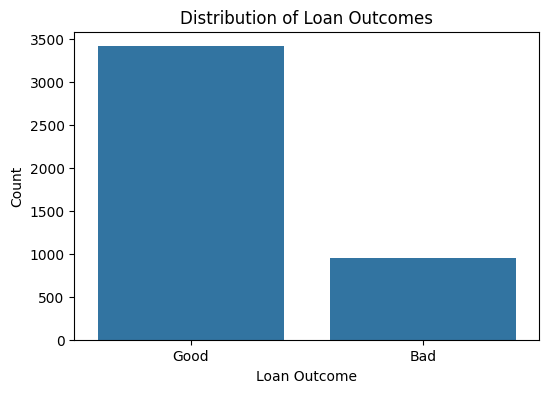

In [ ]:
#Target distribution
print(performance['good_bad_flag'].value_counts())

#Plot
plt.figure(figsize=(6,4))
sns.countplot(x='good_bad_flag', data=performance)
plt.title('Distribution of Loan Outcomes')
plt.xlabel('Loan Outcome')
plt.ylabel('Count')
plt.show()


Target Variable Findings
The target variable analysis shows that 3,416(78.2%) loans are classified as good while  952(21.8%) loans are classified as bad. This indicates a relatively low  default rate with most  of the borrowers succesffully repaying their loans on time. Although te dataset is somewhat imbalanced, the proportion of bad loans could be considered sufficiently  large to support the development of the a predicitive model

In [ ]:
#Percentage distribution
loan_number_pct=pd.crosstab(
    performance['loannumber'],
    performance['good_bad_flag'],
    normalize='index'
)*100
loan_number_pct.round(2)

good_bad_flag,Bad,Good
loannumber,,
2,24.91,75.09
3,26.72,73.28
4,25.06,74.94
5,15.95,84.05
6,22.67,77.33
7,16.27,83.73
8,16.82,83.18
9,16.67,83.33
10,14.66,85.34


There are some variation in loan repayment performance across different loan numbers. while several high loan numbers are associated with relatively high proportion of good lonas, the pattern is not consistent across all borrowing stages. This indicates that loan numbers may capture aspect of customer borrowing behavour and lender confidence but its relationship with loan performance is influenced by other factors

In [ ]:
#Counts and percentages togethr
loan_summary=pd.crosstab(
    performance['loannumber'],
    performance['good_bad_flag']
)
loan_summary["Total"]=loan_summary.sum(axis=1)

loan_pct = pd.crosstab(
    performance['loannumber'],
    performance['good_bad_flag'],
    normalize='index'
) * 100

loan_summary['Bad (%)'] = loan_pct['Bad']
loan_summary['Good (%)'] = loan_pct['Good']

loan_summary


good_bad_flag,Bad,Good,Total,Bad (%),Good (%)
loannumber,,,,,
2,347,1046,1393,24.910266,75.089734
3,179,491,670,26.716418,73.283582
4,111,332,443,25.056433,74.943567
5,52,274,326,15.950920,84.049080
6,56,191,247,22.672065,77.327935
7,41,211,252,16.269841,83.730159
8,37,183,220,16.818182,83.181818
9,30,150,180,16.666667,83.333333
10,28,163,191,14.659686,85.340314




The analysis indicates some variation in loan repayment performance across loan numbers. Customers with loan numbers between 2 and 4 exhibit default rates of approximately 25%, while several subsequent loan numbers show lower default


**Distribution of loan characteristics**

Understanding the distribution of key loan variables provide insightts into customer borrowing behaviour and the structure of the loan portfolio. Variables such as loan amount, total repaymet due, and loan term may influence repayment outcomes and important to examine the before the model development

In [ ]:
loan_vars=['loanamount', 'totaldue', 'loannumber']

performance[loan_vars].describe()

,loanamount,totaldue,loannumber
count,4368.000000,4368.000000,4368.000000
mean,17809.065934,21257.377679,5.172390
std,10749.694571,11943.510416,3.653569
min,10000.000000,10000.000000,2.000000
25%,10000.000000,13000.000000,2.000000
50%,10000.000000,13000.000000,4.000000
75%,20000.000000,24500.000000,7.000000
max,60000.000000,68100.000000,27.000000


The average loan amount is about 17,809 while median is 10,000 which  is considerably lower than the mean , suggesting that large proportion of  customers receive relatively small loans. Loan amounts range from 10,000 to 60,000 whereas repayment obligations range from 10,000 to 68,100

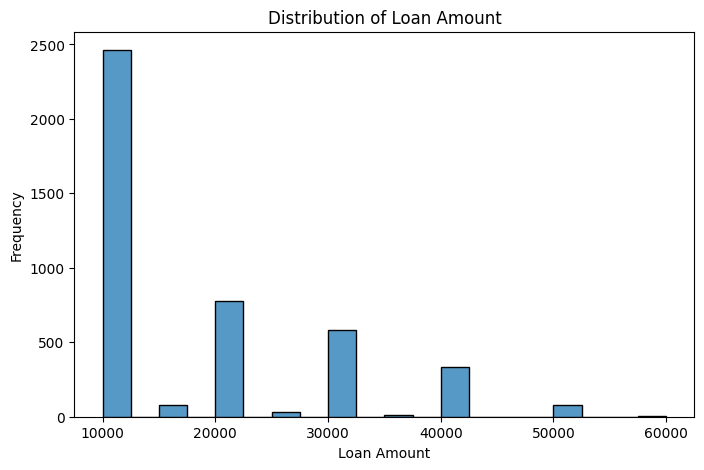

In [ ]:
#Distribution of loan amount

plt.figure(figsize=(8,5))
sns.histplot(performance['loanamount'], bins=20)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

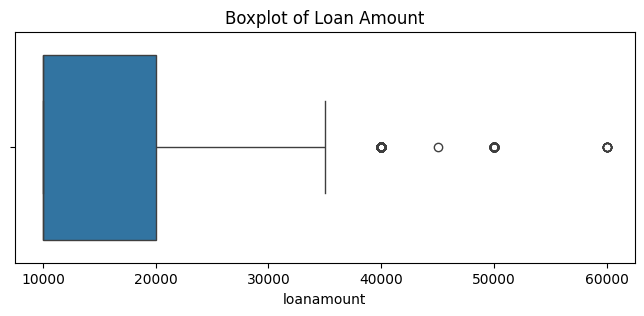

In [ ]:
#Boxplot
plt.figure(figsize=(8,3))
sns.boxplot(x=performance['loanamount'])
plt.title('Boxplot of Loan Amount')
plt.show()


**Distribution of loan term**

The loan term represents the number of days whithin which the borrower is expected to pay the loan. Examining the distribution of loan terms helps identify the most common repayment periods offered by the lender. Loan term may also influence repayment behaviours, as longer repayment periods can affect both affordability and repayment risk


In [ ]:
#Summary of laon term
performance['termdays'].describe()

,termdays
count,4368.000000
mean,29.261676
std,11.512519
min,15.000000
25%,30.000000
50%,30.000000
75%,30.000000
max,90.000000


In [ ]:
#Frequency of loan terms
performance['termdays'].value_counts().sort_index()

,count
termdays,
15,919
30,3129
60,288
90,32


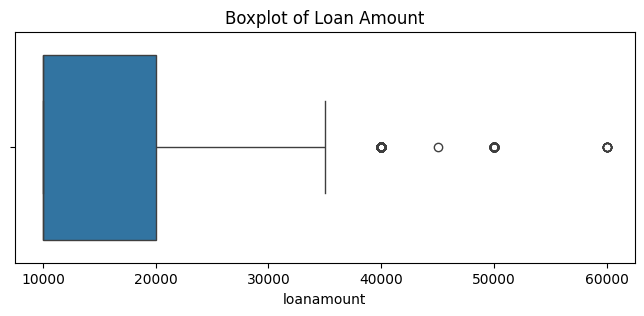

In [ ]:
#Visualize  loan terms
plt.figure(figsize=(8,3))
sns.boxplot(x=performance['loanamount'])
plt.title('Boxplot of Loan Amount')
plt.show()


The distribution shows that a majority of loans are short-term in nature. Most loans have a repayment period of 30 days making it the most dominant loan product in the dataset. A smaller proportion of loans have a 15-day term (919 observations) ,while longer-term loans are less common, with 288 loans issued for 60 days and only 32 loans issued for 90 days

In [ ]:
#Loan term vs default rate
term_default = pd.crosstab(
    performance['termdays'],
    performance['good_bad_flag'],
    normalize='index'
) * 100

term_default

good_bad_flag,Bad,Good
termdays,,
15,22.633297,77.366703
30,21.508469,78.491531
60,22.569444,77.430556
90,18.750000,81.250000


Default reate are relatively similar across loan durations.Notably 90-day loans exhibit a lower observed rate of 18.8% suggesting slightly better repayment performance.However, the sample size for this category is small making the results less reliable

In [ ]:
#Loan amount vs default rate
loan_amt_default = pd.crosstab(
    performance['loanamount'],
    performance['good_bad_flag'],
    normalize='index'
) * 100

loan_amt_default


good_bad_flag,Bad,Good
loanamount,,
10000.0,26.604387,73.395613
15000.0,13.414634,86.585366
20000.0,16.282051,83.717949
25000.0,12.903226,87.096774
30000.0,16.438356,83.561644
35000.0,10.000000,90.000000
40000.0,13.813814,86.186186
45000.0,0.000000,100.000000
50000.0,14.285714,85.714286


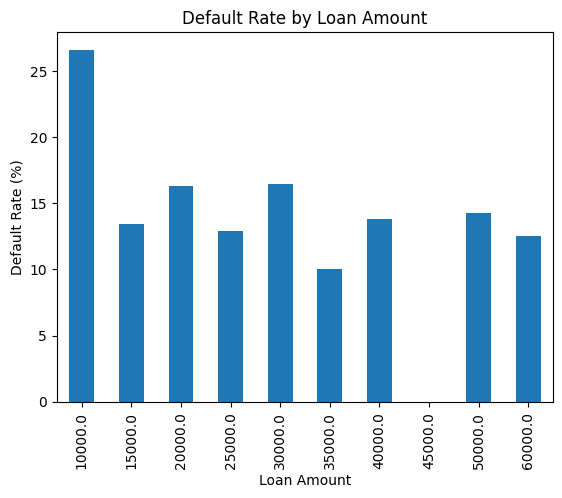

In [ ]:
loan_amt_default['Bad'].plot(kind='bar')
plt.title('Default Rate by Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Default Rate (%)')
plt.show()

The results show some negative relationship between loan amount and default risk, where smaller loans are associated with higher default rates.However, this relationshop should be further validated after merging the datasets and incorportating addtional customer characteristtics

**Loan amount by loan number**
Analyzing the relationship between loan number and loan amount helps to understand how borrowing behavior changes as customers continue to take loans. This can reveal whether repeat borrowers are trusted with higher loan amounts over time, or whether loan sizes remain stable across borrowing cycles.


In [ ]:
performance.groupby('loannumber')['loanamount'].mean()

,loanamount
loannumber,
2,10017.946877
3,10925.373134
4,15981.941309
5,17684.049080
6,18927.125506
7,24246.031746
8,25250.000000
9,28500.000000
10,29685.863874


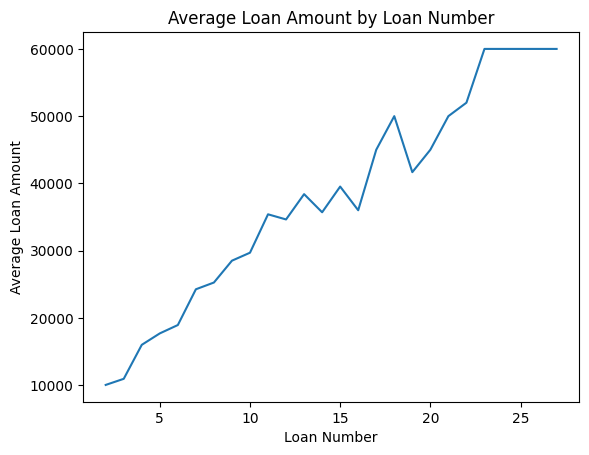

In [ ]:
performance.groupby('loannumber')['loanamount'].mean().plot()

plt.title('Average Loan Amount by Loan Number')
plt.xlabel('Loan Number')
plt.ylabel('Average Loan Amount')
plt.show()

There is a strong positive relationship between loan number and loan amount,reflecting a likely credit growth mechanism where trusted repeate borrowers are eligible for higher loan limits

**Age feature creation **

The customers age will be derived from the birthdate variable to captre potential differences in repayment behaviour across age groups

In [ ]:
#convert dates properly
from datetime import date
performance['approveddate'] = pd.to_datetime(performance['approveddate'])
demographics['birthdate'] = pd.to_datetime(demographics['birthdate'])


In [ ]:
#Merge the files
temp = performance.merge(
    demographics[['customerid', 'birthdate']],
    on='customerid',
    how='left'
)


In [ ]:
temp['age'] = (
    temp['approveddate'].dt.year - temp['birthdate'].dt.year
)

Age distribution of borrowers
The age distribution helps describe the demographic structure of borrwoers in the data set. It provides insight into wich age groups are the most active in borrowing.

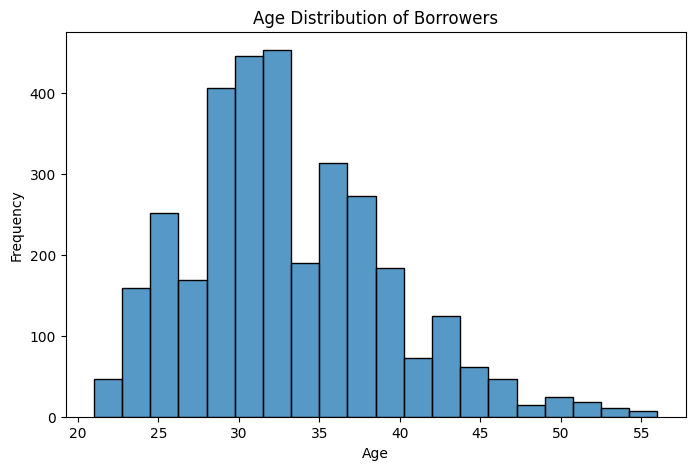

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(temp['age'], bins=20)
plt.title('Age Distribution of Borrowers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Age vs default risk**

This analysis evaluates whether repayment behavior varies across age groups. Age is a key demographic variable in credit risk modeling, as financial stability and repayment discipline may differ across life stages. Understanding this relationship helps identify high-risk or low-risk age segments.


In [ ]:
temp['age_bin'] = pd.cut(
    temp['age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

age_default = pd.crosstab(
    temp['age_bin'],
    temp['good_bad_flag'],
    normalize='index'
) * 100

age_default

good_bad_flag,Bad,Good
age_bin,,
18-25,30.606061,69.393939
26-35,20.867347,79.132653
36-45,20.954598,79.045402
46-55,19.491525,80.508475
56-65,0.000000,100.000000


The analysis shows a clear relationship between age and loan repayment behavior. Borrowers in the 18–25 age group exhibit the highest default rate at approximately 30.6%, indicating that younger customers are significantly riskier compared to other age segments

**Employment status and loan default**

Employment status is a key indicator of a borrower’s financial stability and ability to repay loans. This analysis examines how repayment behavior varies across different employment categories to identify groups with higher or lower default risk. Understanding this relationship helps assess income stability as a driver of credit performance.


In [ ]:

temp = temp.merge(
    demographics[['customerid', 'employment_status_clients']],
    on='customerid',
    how='left'
)


employment_default = pd.crosstab(
    temp['employment_status_clients'],
    temp['good_bad_flag'],
    normalize='index'
) * 100

employment_default

good_bad_flag,Bad,Good
employment_status_clients,,
Contract,0.000000,100.000000
Permanent,20.555556,79.444444
Retired,0.000000,100.000000
Self-Employed,16.245487,83.754513
Student,27.027027,72.972973
Unemployed,16.279070,83.720930
Unknown,30.425963,69.574037


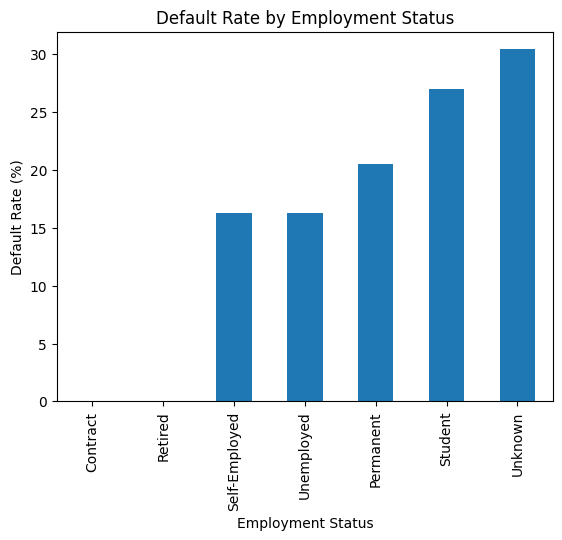

In [ ]:
employment_default['Bad'].sort_values().plot(kind='bar')

plt.title('Default Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Default Rate (%)')
plt.show()

The analysis shows clear differences in loan repayment behavior across employment categories. Students exhibit the highest default rate at approximately 27.0%, followed by customers with unknown employment status at 30.4%, indicating elevated risk in these groups.

**Education level and loan default**

Education level is a proxy for financial literacy, income potential, and employment opportunities. This analysis examines how repayment behavior varies across different education categories to understand whether higher education is associated with lower default risk.

In [ ]:
temp = temp.merge(
    demographics[['customerid', 'level_of_education_clients']],
    on='customerid',
    how='left'
)

education_default = pd.crosstab(
    temp['level_of_education_clients'],
    temp['good_bad_flag'],
    normalize='index'
) * 100

education_default

good_bad_flag,Bad,Good
level_of_education_clients,,
Graduate,17.757009,82.242991
Post-Graduate,22.000000,78.000000
Primary,14.285714,85.714286
Secondary,24.615385,75.384615
Unknown,22.222222,77.777778


The results suggest a mixed relationship between education level and loan default risk. While higher education generally shows moderate to lower default rates compared to secondary education, the pattern is not strictly linear.

**Aggregate Previous Loans **

The previous loans dataset contains multiple loan records per customer. To incorporate this information into a modeling dataset, it is necessary to aggregate the data at customer level. This allows historical borrowing behavior to be summarized into meaningful features such as frequency of borrowing, average loan size, and total exposure, which are important indicators of credit risk.



In [ ]:
# Ensure dates are in correct format
previous['approveddate'] = pd.to_datetime(previous['approveddate'])
previous['closeddate'] = pd.to_datetime(previous['closeddate'])

# Aggregate features at customer level
prev_agg = previous.groupby('customerid').agg(
    prev_loan_count=('systemloanid', 'count'),
    prev_avg_loan=('loanamount', 'mean'),
    prev_total_loan=('loanamount', 'sum'),
    prev_avg_due=('totaldue', 'mean'),
    prev_avg_term=('termdays', 'mean')
).reset_index()

prev_agg.head()

,customerid,prev_loan_count,prev_avg_loan,prev_total_loan,prev_avg_due,prev_avg_term
0,8a1088a0484472eb01484669e3ce4e0b,1,10000.000000,10000.0,11500.000000,15.000000
1,8a1a1e7e4f707f8b014f797718316cad,4,17500.000000,70000.0,22375.000000,37.500000
2,8a1a32fc49b632520149c3b8fdf85139,7,12857.142857,90000.0,15214.285714,19.285714
3,8a1eb5ba49a682300149c3c068b806c7,8,16250.000000,130000.0,20300.000000,33.750000
4,8a1edbf14734127f0147356fdb1b1eb2,2,10000.000000,20000.0,12250.000000,22.500000


**Merging all data sources **
The final modeling dataset is created by merging performance data with demographic information and aggregated previous loan features. This ensures that each loan observation contains both current loan attributes and historical customer behavior, enabling the model to learn patterns associated with credit risk.


In [ ]:
# Start with performance dataset
final_df = performance.copy()

# Merge demographics
final_df = final_df.merge(
    demographics,
    on='customerid',
    how='left'
)

# Merge previous loan aggregates
final_df = final_df.merge(
    prev_agg,
    on='customerid',
    how='left'
)

In [ ]:
# Fill missing previous loan info (new customers)
final_df['prev_loan_count'] = final_df['prev_loan_count'].fillna(0)
final_df['prev_avg_loan'] = final_df['prev_avg_loan'].fillna(0)
final_df['prev_total_loan'] = final_df['prev_total_loan'].fillna(0)
final_df['prev_avg_due'] = final_df['prev_avg_due'].fillna(0)
final_df['prev_avg_term'] = final_df['prev_avg_term'].fillna(0)

MACHINE LEARNING PHASE

**Feature preparation for modeling**

Machine learning models require all input variables to be in numerical format. Therefore, categorical variables must be encoded, and the dataset must be split into features (X) and target (y). This step ensures that the data is properly structured for model training and evaluation.


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customerid                  4368 non-null   object        
 1   systemloanid                4368 non-null   int64         
 2   loannumber                  4368 non-null   int64         
 3   approveddate                4368 non-null   datetime64[ns]
 4   creationdate                4368 non-null   datetime64[ns]
 5   loanamount                  4368 non-null   float64       
 6   totaldue                    4368 non-null   float64       
 7   termdays                    4368 non-null   int64         
 8   referredby                  4368 non-null   object        
 9   good_bad_flag               4368 non-null   object        
 10  birthdate                   3269 non-null   datetime64[ns]
 11  bank_account_type           3269 non-null   object      

In [ ]:
# Target variable
y = final_df['good_bad_flag'].map({'Good': 1, 'Bad': 0})

# Drop unnecessary columns
X = final_df.drop([
    'good_bad_flag',
    'customerid',
    'systemloanid',
    'approveddate',
    'creationdate',
    'birthdate'
], axis=1)

In [ ]:
#Handle missing values

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('Unknown')
    else:
        X[col] = X[col].fillna(0)

In [ ]:
#Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Baseline model (Logistic regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print("AUC Score:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       190
           1       0.78      1.00      0.88       684

    accuracy                           0.78       874
   macro avg       0.39      0.50      0.44       874
weighted avg       0.61      0.78      0.69       874

AUC Score: 0.613123268698061


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_val)
y_prob = rf.predict_proba(X_val)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_val, y_pred))
print("AUC Score:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.30      0.18      0.23       190
           1       0.80      0.89      0.84       684

    accuracy                           0.73       874
   macro avg       0.55      0.53      0.53       874
weighted avg       0.69      0.73      0.70       874

AUC Score: 0.569625269313635


PREPARE TEST DATA

In [ ]:
test_perf = pd.read_csv('testperf.csv')
test_demo = pd.read_csv('testdemographics.csv')
test_prev = pd.read_csv('testprevloans.csv')

In [ ]:
test_prev['approveddate'] = pd.to_datetime(test_prev['approveddate'])
test_prev['closeddate'] = pd.to_datetime(test_prev['closeddate'])

test_prev_agg = test_prev.groupby('customerid').agg(
    prev_loan_count=('systemloanid', 'count'),
    prev_avg_loan=('loanamount', 'mean'),
    prev_total_loan=('loanamount', 'sum'),
    prev_avg_due=('totaldue', 'mean'),
    prev_avg_term=('termdays', 'mean')
).reset_index()

In [ ]:
test_df = test_perf.merge(
    test_demo,
    on='customerid',
    how='left'
)

test_df = test_df.merge(
    test_prev_agg,
    on='customerid',
    how='left'
)

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customerid                  1450 non-null   object        
 1   systemloanid                1450 non-null   int64         
 2   loannumber                  1450 non-null   int64         
 3   approveddate                597 non-null    datetime64[ns]
 4   creationdate                1450 non-null   object        
 5   loanamount                  1450 non-null   int64         
 6   totaldue                    1450 non-null   float64       
 7   termdays                    1450 non-null   int64         
 8   referredby                  184 non-null    object        
 9   birthdate                   385 non-null    datetime64[ns]
 10  bank_account_type           385 non-null    object        
 11  longitude_gps               385 non-null    float64     

In [ ]:
for col in test_df.columns:
    if test_df[col].dtype == 'object':
        test_df[col] = test_df[col].fillna('Unknown')
    else:
        test_df[col] = test_df[col].fillna(0)

In [ ]:
test_X = test_df.drop([
    'customerid',
    'systemloanid',
    'approveddate',
    'creationdate',
    'birthdate',
    'closeddate',
    'firstduedate',
    'firstrepaiddate'
], axis=1)

KeyError: "['closeddate', 'firstduedate', 'firstrepaiddate'] not found in axis"

In [ ]:
test_X = pd.get_dummies(test_X, drop_first=True)

# align columns with training set
test_X = test_X.reindex(columns=X.columns, fill_value=0)

NameError: name 'test_X' is not defined